# Phase 2 — Weekly Series Construction

Builds ISO-week (Monday-start) demand panels for every product (and every
product × country pair) from the cleaned transaction parquet.
Figures 09–12 are saved to `outputs/figures/` at 140 dpi.

In [1]:
import sys
from pathlib import Path

ROOT = Path().resolve()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import matplotlib.colors as mcolors

from src.weekly_series import build_weekly_product, build_weekly_product_country

FIGS = ROOT / "outputs" / "figures"
FIGS.mkdir(parents=True, exist_ok=True)

# ── Same project-wide style as Phase 1 ────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi"        : 100,
    "savefig.dpi"       : 140,
    "figure.facecolor"  : "white",
    "axes.facecolor"    : "#f8f8f8",
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
    "axes.grid"         : True,
    "grid.alpha"        : 0.35,
    "grid.color"        : "#cccccc",
    "font.family"       : "sans-serif",
    "font.size"         : 10,
    "axes.titlesize"    : 12,
    "axes.titleweight"  : "bold",
    "axes.labelsize"    : 10,
    "xtick.labelsize"   : 9,
    "ytick.labelsize"   : 9,
    "legend.fontsize"   : 9,
    "legend.frameon"    : False,
})
C = ["#2E86AB", "#A23B72", "#F18F01", "#C73E1D", "#3B1F2B", "#44BBA4"]

def savefig(fig, name):
    fig.savefig(FIGS / name, bbox_inches="tight", dpi=140)
    print(f"Saved -> {name}")


In [2]:
# ── Build / reload panels ─────────────────────────────────────────────────────
PRODUCT_PARQUET = ROOT / "data" / "processed" / "weekly_product.parquet"
PC_PARQUET      = ROOT / "data" / "processed" / "weekly_product_country.parquet"

# Re-run builders only if parquets don't exist yet
if not PRODUCT_PARQUET.exists():
    print("Building product panel …")
    prod_summary = build_weekly_product(
        parquet_out=PRODUCT_PARQUET,
    )
else:
    print("Loading existing product panel …")

if not PC_PARQUET.exists():
    print("Building product × country panel …")
    pc_summary = build_weekly_product_country(
        parquet_out=PC_PARQUET,
        global_last=pd.Timestamp("2025-09-08"),
    )
else:
    print("Loading existing product × country panel …")

panel = pd.read_parquet(PRODUCT_PARQUET)
panel["week_start"] = pd.to_datetime(panel["week_start"])
panel["first_sale_week"] = pd.to_datetime(panel["first_sale_week"])
print(f"Product panel loaded: {len(panel):,} rows × {panel.shape[1]} cols")


Loading existing product panel …
Loading existing product × country panel …


Product panel loaded: 1,521,270 rows × 8 cols


In [3]:
# ── Phase 2 summary ───────────────────────────────────────────────────────────
global_first = panel["week_start"].min()
global_last  = panel["week_start"].max()
n_weeks      = panel["week_start"].nunique()

total_span = panel.groupby("ProductID")["weeks_since_first_sale"].max() + 1
active_ratio = panel.groupby("ProductID")["n_active_weeks"].first() / total_span

SEP = "=" * 62
print(SEP)
print("PHASE 2 SUMMARY — Weekly Series Construction")
print(SEP)
print(f"  Global first week              {global_first.date()}")
print(f"  Global last week (complete)    {global_last.date()}")
print(f"  Total ISO weeks in panel       {n_weeks}")
print(f"  Rows trimmed (partial week)    120")
print()
print(f"  Product-week rows              {len(panel):>12,}")
print(f"  Products in panel              {panel['ProductID'].nunique():>12,}")
print(f"  Overall zero-week share        {(panel['qty'] == 0).mean():>11.2%}")
print(f"  Median active-week ratio       {active_ratio.median():>11.2%}")
print(f"  Median n_active_weeks          {panel.groupby('ProductID')['n_active_weeks'].first().median():>12.0f}")
print(SEP)


PHASE 2 SUMMARY — Weekly Series Construction
  Global first week              2022-02-28
  Global last week (complete)    2025-09-08
  Total ISO weeks in panel       185
  Rows trimmed (partial week)    120

  Product-week rows                 1,521,270
  Products in panel                    13,707


  Overall zero-week share             96.27%
  Median active-week ratio             2.54%
  Median n_active_weeks                     2


Saved -> 09_example_series.png


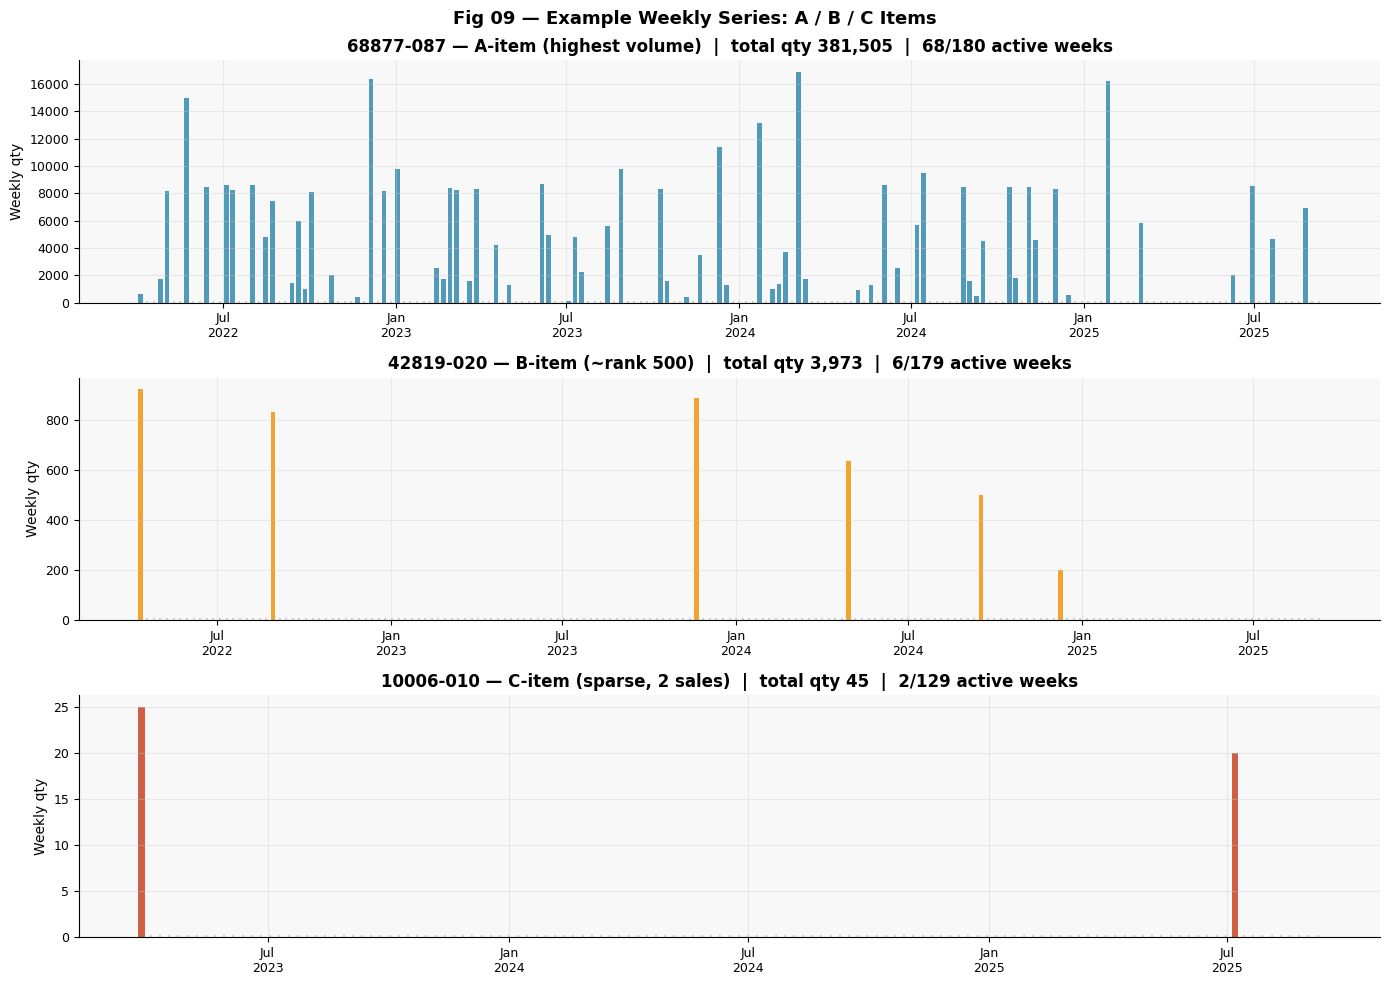

In [4]:
# ── Fig 09 — Example weekly series: A / B / C items ──────────────────────────
prod_totals = panel.groupby("ProductID")["total_qty"].first().sort_values(ascending=False)
n_prod = len(prod_totals)

# A item: top product by total qty
a_pid = prod_totals.index[0]
# B item: ~500th ranked product (inside the 80% cumulative group ≈ top 677)
b_pid = prod_totals.index[min(500, n_prod - 1)]
# C item: a sparse product with exactly 2 active weeks and long span (≥ 50 weeks)
sparse_cands = (
    panel.groupby("ProductID")
    .filter(lambda x: (x["n_active_weeks"].iloc[0] == 2)
                      and (len(x) >= 50))["ProductID"]
    .unique()
)
c_pid = sparse_cands[0] if len(sparse_cands) else prod_totals.index[-1]

items = [(a_pid, "A-item (highest volume)",  C[0]),
         (b_pid, "B-item (~rank 500)",        C[2]),
         (c_pid, "C-item (sparse, 2 sales)",  C[3])]

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=False)
fig.suptitle("Fig 09 — Example Weekly Series: A / B / C Items", fontsize=13, fontweight="bold")

for ax, (pid, label, col) in zip(axes, items):
    s = panel[panel["ProductID"] == pid].sort_values("week_start")
    ax.bar(s["week_start"], s["qty"], width=5, color=col, alpha=0.82, label=label)
    # Mark zero weeks as faint background
    zero_wks = s[s["qty"] == 0]["week_start"]
    ax.scatter(zero_wks, [0] * len(zero_wks), marker="|", color="#aaaaaa",
               s=10, zorder=1, alpha=0.5)
    ax.set_title(f"{pid} — {label}  |  total qty {s['qty'].sum():,.0f}  "
                 f"|  {s['n_active_weeks'].iloc[0]}/{len(s)} active weeks")
    ax.set_ylabel("Weekly qty")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))
    ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 7]))

plt.tight_layout()
savefig(fig, "09_example_series.png")
plt.show()


Saved -> 10_total_weekly_demand.png


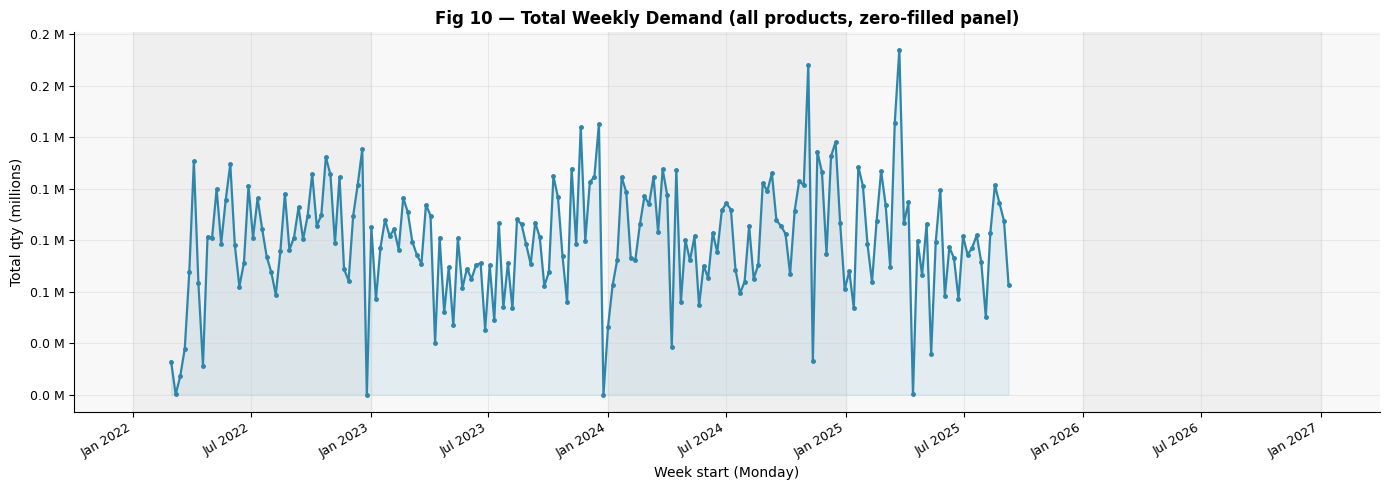

In [5]:
# ── Fig 10 — Total weekly demand across all products ─────────────────────────
weekly_agg = panel.groupby("week_start")["qty"].sum().reset_index()
weekly_agg.columns = ["week_start", "total_qty"]

fig, ax = plt.subplots(figsize=(14, 5))
ax.set_title("Fig 10 — Total Weekly Demand (all products, zero-filled panel)")

ax.plot(weekly_agg["week_start"], weekly_agg["total_qty"] / 1e6,
        color=C[0], lw=1.6, marker="o", ms=2.5)
ax.fill_between(weekly_agg["week_start"], weekly_agg["total_qty"] / 1e6,
                alpha=0.10, color=C[0])

# Shade calendar years
for yr in range(weekly_agg["week_start"].dt.year.min(),
                weekly_agg["week_start"].dt.year.max() + 2):
    if yr % 2 == 0:
        ax.axvspan(pd.Timestamp(f"{yr}-01-01"), pd.Timestamp(f"{yr+1}-01-01"),
                   color="#e8e8e8", alpha=0.5, zorder=0)

ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 7]))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right")
ax.set_xlabel("Week start (Monday)")
ax.set_ylabel("Total qty (millions)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.1f} M"))

plt.tight_layout()
savefig(fig, "10_total_weekly_demand.png")
plt.show()


Saved -> 11_demand_calendar_heatmap.png


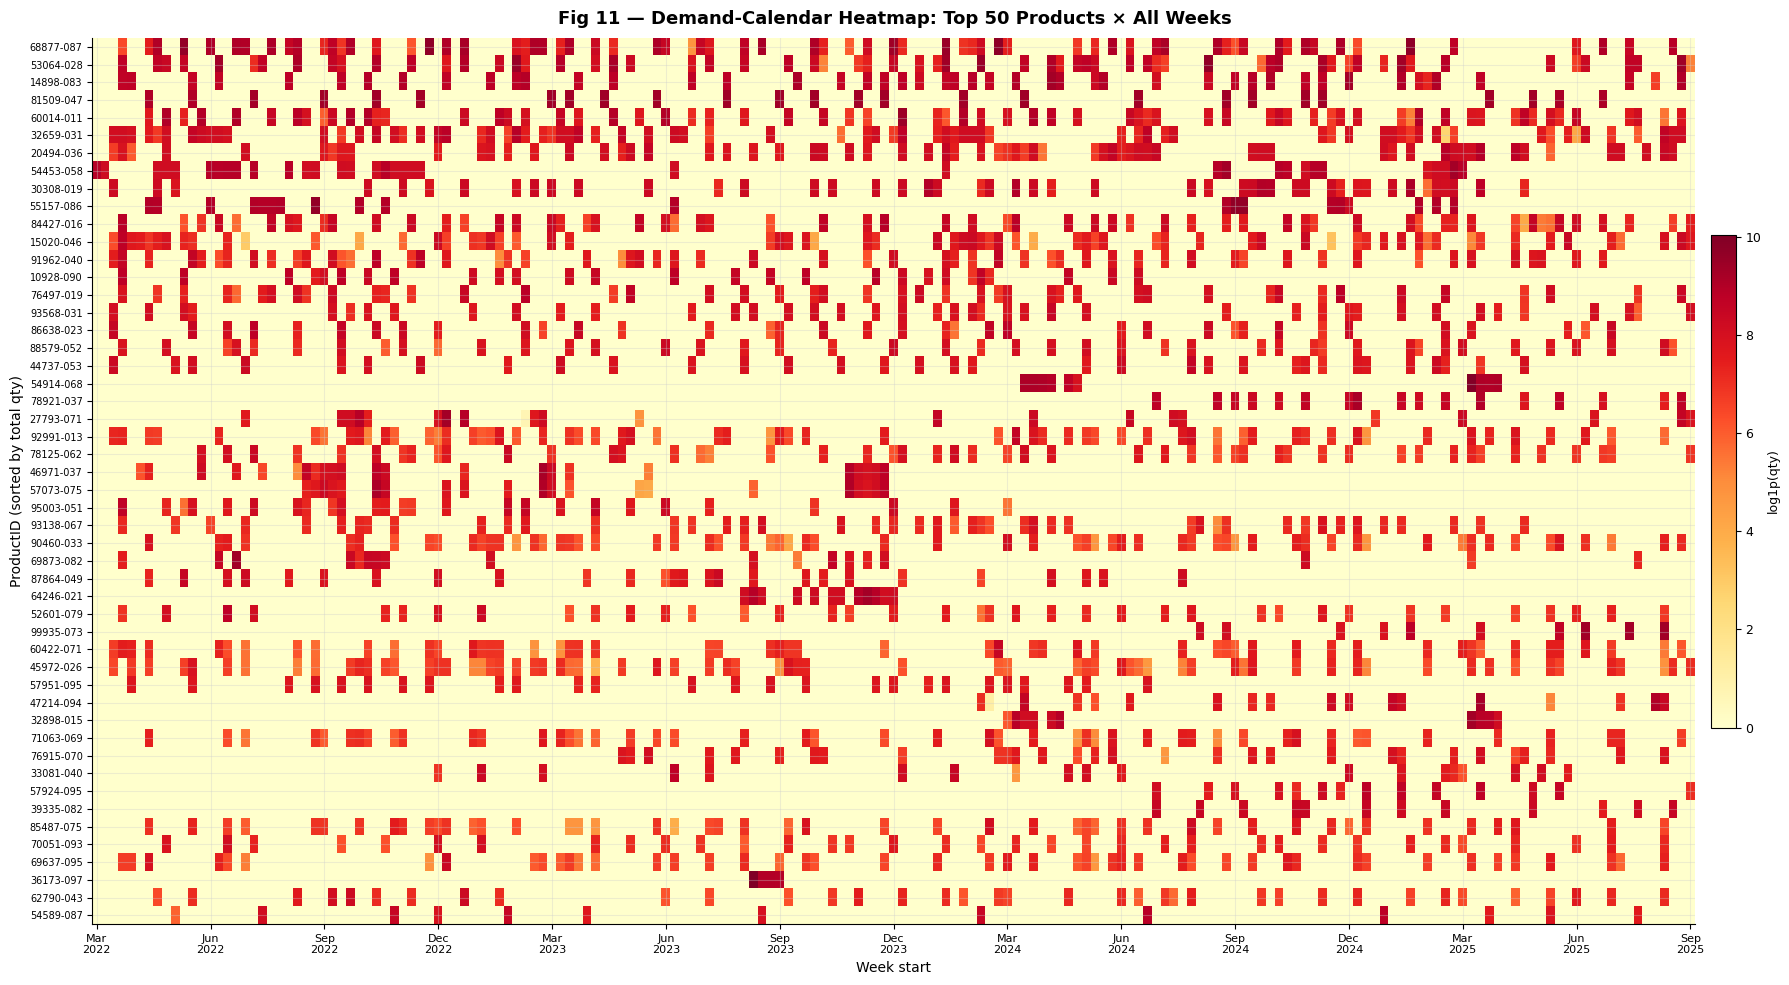

In [6]:
# ── Fig 11 — Demand-calendar heatmap (top-50 products × all weeks) ────────────
TOP_N = 50
top50 = prod_totals.head(TOP_N).index.tolist()

hm = (
    panel[panel["ProductID"].isin(top50)]
    .pivot_table(index="ProductID", columns="week_start", values="qty", fill_value=0)
)
hm = hm.loc[top50]   # sort rows by total_qty descending

# Log1p transform so sparse products are visible alongside high-volume ones
hm_log = np.log1p(hm.values)

fig, ax = plt.subplots(figsize=(18, 10))
fig.suptitle(f"Fig 11 — Demand-Calendar Heatmap: Top {TOP_N} Products × All Weeks",
             fontsize=13, fontweight="bold")

im = ax.imshow(hm_log, aspect="auto", cmap="YlOrRd",
               interpolation="nearest", origin="upper")

# X-axis: sample every ~13 weeks (~quarterly) so labels don't crowd
week_labels = list(hm.columns)
tick_step = max(1, len(week_labels) // 14)
ax.set_xticks(range(0, len(week_labels), tick_step))
ax.set_xticklabels(
    [pd.Timestamp(w).strftime("%b\n%Y") for w in week_labels[::tick_step]],
    fontsize=8,
)
# Y-axis: product IDs (abbreviated)
ax.set_yticks(range(TOP_N))
ax.set_yticklabels([pid[:9] for pid in top50], fontsize=7)
ax.set_xlabel("Week start")
ax.set_ylabel("ProductID (sorted by total qty)")

cbar = fig.colorbar(im, ax=ax, fraction=0.015, pad=0.01)
cbar.set_label("log1p(qty)", fontsize=9)

plt.tight_layout()
savefig(fig, "11_demand_calendar_heatmap.png")
plt.show()


Saved -> 12_active_week_ratio.png


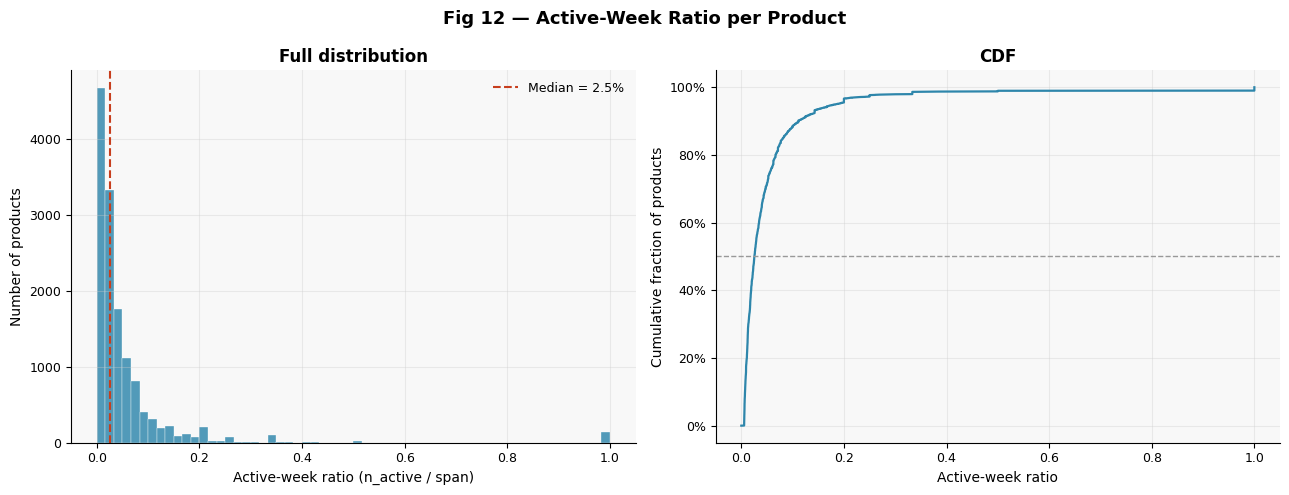

In [7]:
# ── Fig 12 — Active-week ratio histogram ──────────────────────────────────────
prod_meta = panel.groupby("ProductID").agg(
    n_active=("n_active_weeks", "first"),
    span=("weeks_since_first_sale", "max"),
)
prod_meta["active_ratio"] = prod_meta["n_active"] / (prod_meta["span"] + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Fig 12 — Active-Week Ratio per Product", fontsize=13, fontweight="bold")

# Left: histogram of active-week ratio
ax = axes[0]
ax.hist(prod_meta["active_ratio"], bins=60, color=C[0], alpha=0.82, edgecolor="white", lw=0.3)
ax.axvline(prod_meta["active_ratio"].median(), color=C[3], ls="--", lw=1.5,
           label=f"Median = {prod_meta['active_ratio'].median():.1%}")
ax.set_xlabel("Active-week ratio (n_active / span)")
ax.set_ylabel("Number of products")
ax.set_title("Full distribution")
ax.legend()

# Right: cumulative distribution
ax2 = axes[1]
sorted_r = np.sort(prod_meta["active_ratio"].values)
ax2.plot(sorted_r, np.linspace(0, 1, len(sorted_r)), color=C[0], lw=1.6)
ax2.axhline(0.5, ls="--", lw=1, color="#999999")
ax2.set_xlabel("Active-week ratio")
ax2.set_ylabel("Cumulative fraction of products")
ax2.set_title("CDF")
ax2.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

plt.tight_layout()
savefig(fig, "12_active_week_ratio.png")
plt.show()


In [8]:
print("\nPhase 2 figures saved:")
for f in sorted(p for p in (ROOT / "outputs" / "figures").iterdir()
                if p.stem.startswith(("09","10","11","12"))):
    print(f"  {f.name}  ({f.stat().st_size // 1024} KB)")



Phase 2 figures saved:
  09_example_series.png  (96 KB)
  10_total_weekly_demand.png  (131 KB)
  11_demand_calendar_heatmap.png  (170 KB)
  12_active_week_ratio.png  (59 KB)
